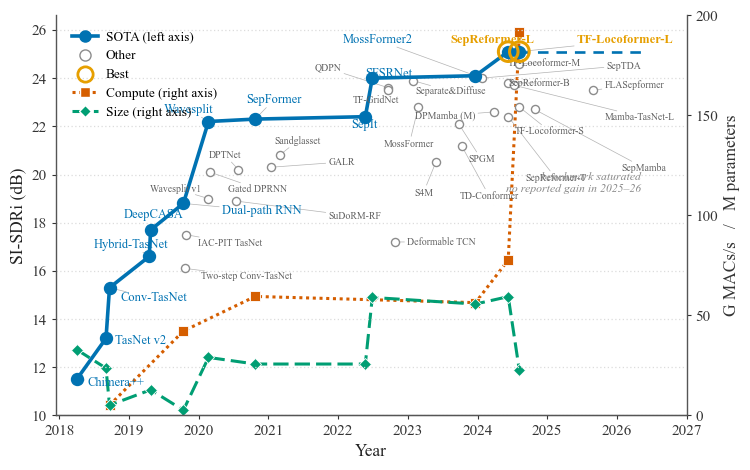

In [9]:
"""
plot_wsj0_2mix_sota.py
Reproduce the WSJ0-2mix "SOTA over time" v6 plot (SI-SDRi on the left axis,
frontier compute in G MACs/s on the right axis) from plain lists.

Requires: matplotlib, and (optionally) adjustText for non-overlapping labels
    pip install matplotlib adjustText
"""
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

try:
    from adjustText import adjust_text
    _HAS_ADJUST = True
except ImportError:                       # labels still drawn, just not de-overlapped
    _HAS_ADJUST = False
    import warnings
    warnings.warn("adjustText not installed -> labels will overlap. "
                  "Fix with:  pip install -U 'adjustText>=1.0'")

# Okabe-Ito colourblind-safe palette
NAVY, ORANGE, VERM = "#0072B2", "#E69F00", "#D55E00"
GREEN = "#009E73"                          # parameter-count line
GREY_EDGE, GREY_TXT, GRID = "#8c8c8c", "#5f5f5f", "#dcdcdc"


def plot_wsj0_2mix_sota(names, si_sdri, macs, dates, params=None,
                        today=2026.45,
                        note="benchmark saturated\nno reported gain in 2025\u201326",
                        show_params=True, save_prefix=None):
    """
    names, si_sdri, dates : equal-length lists (dates as decimal years, e.g. 2020.81)
    macs                  : G MACs/s per model; use None where not reported
    params                : #params (millions); use None where not reported.
                            Plotted as a 2nd (offset) right axis when show_params=True.
    today                 : right end of the dashed "plateau" line (decimal year)
    show_params           : if True and params given, add the model-size axis/line
    save_prefix           : if given, writes <prefix>.pdf/.svg/.png
    Returns (fig, ax). The frontier is computed as the strict running-max of SI-SDRi.
    """
    _params_on = show_params and params is not None
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Liberation Serif", "Tinos", "DejaVu Serif"],
        "svg.fonttype": "none",   # SVG keeps live text referencing Times New Roman
        "pdf.fonttype": 42,
    })
    n = len(names)

    # order by date, breaking ties by SI-SDRi desc so the best at a date defines the envelope
    order = sorted(range(n), key=lambda i: (dates[i], -si_sdri[i]))
    frontier, run = [], float("-inf")
    for i in order:
        if si_sdri[i] > run:
            frontier.append(i); run = si_sdri[i]
    gmax = max(si_sdri)
    best = [i for i in range(n) if si_sdri[i] == gmax]          # current-best (ties allowed)
    fset, bset = set(frontier), set(best)
    fb = sorted(fset | bset, key=lambda i: dates[i])

    fig, ax = plt.subplots(figsize=(7.6, 4.8))  # ~text width -> large print fonts
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color=GRID, linewidth=0.9, linestyle=(0, (1, 2)))
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("#555"); ax.spines[s].set_linewidth(1.0)
    ax.tick_params(length=3, colors="#333", labelsize=11)

    # other models -> hollow grey circles
    others = [i for i in range(n) if i not in fset and i not in bset]
    ax.scatter([dates[i] for i in others], [si_sdri[i] for i in others],
               s=34, facecolors="white", edgecolors=GREY_EDGE, linewidths=1.0, zorder=2)

    # frontier line, then plateau to `today` (passing through any later co-best points)
    fx = [dates[i] for i in frontier]; fy = [si_sdri[i] for i in frontier]
    ax.plot(fx, fy, color=NAVY, linewidth=2.6, zorder=3, solid_capstyle="round")
    later_best = [i for i in sorted(best, key=lambda i: dates[i]) if dates[i] > fx[-1]]
    chain_x = [fx[-1]] + [dates[i] for i in later_best]
    chain_y = [fy[-1]] + [si_sdri[i] for i in later_best]
    if len(chain_x) > 1:
        ax.plot(chain_x, chain_y, color=NAVY, linewidth=2.6, zorder=3, solid_capstyle="round")
    ax.plot([chain_x[-1], today], [gmax, gmax], color=NAVY, linewidth=1.9,
            linestyle=(0, (4, 3)), zorder=3)

    # markers + current-best rings
    ax.scatter([dates[i] for i in fb], [si_sdri[i] for i in fb], s=74, color=NAVY, zorder=4)
    ax.scatter([dates[i] for i in best], [si_sdri[i] for i in best], s=200,
               facecolors="none", edgecolors=ORANGE, linewidths=2.2, zorder=5)

    # labels for every point
    texts = []
    for i in range(n):
        if i in bset:
            col, w, fs = ORANGE, "bold", 9
        elif i in fset:
            col, w, fs = NAVY, "normal", 9
        else:
            col, w, fs = GREY_TXT, "normal", 7
        texts.append(ax.text(dates[i], si_sdri[i], names[i], color=col, weight=w, fontsize=fs))
    if _HAS_ADJUST:
        arrow = dict(arrowstyle="-", color="#b3b3b3", lw=0.5)
        try:                              # adjustText >= 1.0 API
            adjust_text(texts, x=list(dates), y=list(si_sdri), ax=ax,
                        expand=(1.25, 1.9), force_text=(0.45, 0.95),
                        only_move={"static": "xy"}, arrowprops=arrow)
        except Exception:                 # older adjustText -> minimal, always-valid call
            adjust_text(texts, ax=ax, arrowprops=arrow)

    if note:
        ax.text(today - 0.1, gmax - 5.0, note, ha="right", va="top",
                fontsize=8.5, style="italic", color="#888", linespacing=1.3)

    ax.set_ylabel("SI-SDRi (dB)", fontsize=12.5, color="#222")
    ax.set_xlabel("Year", fontsize=12.5, color="#222")
    ax.set_ylim(min(si_sdri) - 1.5, gmax + 1.5)
    ax.set_xlim(min(dates) - 0.3, today + 0.2)
    ax.set_xticks(range(int(min(dates)), int(today) + 2))

    # single right axis (0-200) carrying BOTH compute (MACs) and size (params)
    ax2 = ax.twinx()
    ax.set_zorder(ax2.get_zorder() + 1); ax.patch.set_visible(False)  # keep labels on top
    macs_idx = [i for i in fb if macs[i] is not None]
    ax2.plot([dates[i] for i in macs_idx], [macs[i] for i in macs_idx],
             color=VERM, linestyle=(0, (1, 1.2)), linewidth=2.2, marker="s",
             markersize=6.5, markerfacecolor=VERM, markeredgecolor="white",
             markeredgewidth=0.6, zorder=2)
    if _params_on:
        p_idx = [i for i in fb if params[i] is not None]
        ax2.plot([dates[i] for i in p_idx], [params[i] for i in p_idx],
                 color=GREEN, linestyle=(0, (5, 2)), linewidth=2.2, marker="D",
                 markersize=6, markerfacecolor=GREEN, markeredgecolor="white",
                 markeredgewidth=0.6, zorder=2)
    ax2.set_ylim(0, 200)
    ax2.set_yticks(range(0, 201, 50))
    ax2.set_ylabel("G MACs/s   /   M parameters" if _params_on
                   else "Frontier compute (G MACs/s)", color="#333", fontsize=12.5)
    ax2.tick_params(axis="y", colors="#333", length=3, labelsize=11)
    for s in ("top", "left"):
        ax2.spines[s].set_visible(False)
    ax2.spines["right"].set_color("#555"); ax2.spines["right"].set_linewidth(1.0)
    ax2.grid(False)

    handles = [
        Line2D([0], [0], marker="o", color=NAVY, markerfacecolor=NAVY,
               markersize=8, linewidth=2.6, label="SOTA (left axis)"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="white",
               markeredgecolor=GREY_EDGE, markersize=8, label="Other"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="none",
               markeredgecolor=ORANGE, markersize=11, markeredgewidth=2.0,
               label=f"Best"),
        Line2D([0], [0], color=VERM, linestyle=(0, (1, 1.2)), linewidth=2.2,
               marker="s", markersize=6.5, markerfacecolor=VERM,
               markeredgecolor="white", label="Compute (right axis)"),
    ]
    if _params_on:
        handles.append(
            Line2D([0], [0], color=GREEN, linestyle=(0, (5, 2)), linewidth=2.2,
                   marker="D", markersize=6, markerfacecolor=GREEN,
                   markeredgecolor="white", label="Size (right axis)"))
    ax.legend(handles=handles, loc="upper left", frameon=False, fontsize=9.5,
              handletextpad=0.6, borderaxespad=0.8)

    fig.tight_layout()
    if save_prefix:
        for ext in ("pdf", "svg", "png"):
            fig.savefig(f"{save_prefix}.{ext}", bbox_inches="tight", dpi=200)
    return fig, ax


# ---------------------------------------------------------------------------
# Data (chronological).  `dates` are decimal years and are REQUIRED for the
# time axis; they are not in the four value-lists, so they live here.
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    names = [
        "Chimera++", "TasNet v2", "Conv-TasNet", "Hybrid-TasNet", "DeepCASA",
        "Dual-path RNN", "Two-step Conv-TasNet", "IAC-PIT TasNet", "Wavesplit v1",
        "Wavesplit", "Gated DPRNN", "SuDoRM-RF", "DPTNet", "SepFormer", "GALR",
        "Sandglasset", "SepIt", "SFSRNet", "QDPN", "TF-GridNet", "Deformable TCN",
        "Separate&Diffuse", "MossFormer", "S4M", "SPGM", "TD-Conformer",
        "MossFormer2", "SepTDA", "DPMamba (M)", "SepReformer-T", "SepReformer-B",
        "SepReformer-L", "Mamba-TasNet-L", "TF-Locoformer-S", "TF-Locoformer-M",
        "TF-Locoformer-L", "SepMamba", "FLASepformer",
    ]
    si_sdri = [
        11.5, 13.2, 15.3, 16.6, 17.7, 18.8, 16.1, 17.5, 19.0, 22.2, 20.1, 18.9,
        20.2, 22.3, 20.3, 20.8, 22.4, 24.0, 23.6, 23.5, 17.2, 23.9, 22.8, 20.5,
        22.1, 21.2, 24.1, 24.0, 22.6, 22.4, 23.8, 25.1, 23.7, 22.8, 24.6, 25.1,
        22.7, 23.5,
    ]
    macs = [
        None, None, 5.1, None, None, 42.2, None, None, None, None, None, None,
        None, 59.5, None, None, None, None, None, 231.1, None, None, 42.7, None,
        None, None, 56.4, None, None, 5.2, 19.9, 77.7, None, 43.7, 127.8, 191.7,
        None, None,
    ]
    params = [
        32.9, 23.6, 5.1, None, 12.8, 2.6, 8.6, None, 29.0, 29.0, 7.5, 6.4, 2.7,
        25.7, 2.3, 2.3, 25.7, 59.0, 200.0, 14.4, None, None, 42.1, 3.6, 26.2, None,
        55.7, 21.2, 15.9, 3.7, 14.2, 59.4, 59.6, 5.0, 15.0, 22.5, None, None,
    ]
    dates = [
        2018.25, 2018.67, 2018.72, 2019.29, 2019.31, 2019.78, 2019.81, 2019.82,
        2020.14, 2020.14, 2020.16, 2020.53, 2020.57, 2020.81, 2021.03, 2021.16,
        2022.39, 2022.49, 2022.72, 2022.72, 2022.82, 2023.07, 2023.15, 2023.40,
        2023.73, 2023.77, 2023.97, 2024.06, 2024.24, 2024.44, 2024.44, 2024.44,
        2024.53, 2024.60, 2024.60, 2024.60, 2024.82, 2025.65,
    ]

    plot_wsj0_2mix_sota(names, si_sdri, macs, dates, params,
                        save_prefix="wsj0_2mix_sota_v6")
    plt.show()